# Preliminary

In [1]:
%cd /root/autodl-tmp/Q-Vtree
import json
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import pandas as pd

from InternVL.evaluate import (
    extract_option_letter,
    decode_base64_image,
    run_vstar_inference_internvl,
    evaluate_vstar_predictions,
    run_hrbench_inference_internvl,
    evaluate_hrbench_predictions,
)

/root/miniconda3/envs/mllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/root/autodl-tmp/Q-Vtree


In [2]:
%cd /root/autodl-tmp/Q-Vtree
import torch
from transformers import AutoTokenizer
from InternVL.global_compact import InternVLChatModelWithTree

model_path = "checkpoints/InternVL3-8B"

tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

tree_model = InternVLChatModelWithTree.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
).eval()

tree_model.img_context_token_id = tokenizer.convert_tokens_to_ids('<IMG_CONTEXT>')

print("Model class:", tree_model.__class__.__name__)
print("Tree model loaded:", model_path)

/root/miniconda3/envs/mllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/root/miniconda3/envs/mllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/root/autodl-tmp/Q-Vtree
FlashAttention2 is not installed.


The tokenizer you are loading from 'checkpoints/InternVL3-8B' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Loading weights: 100%|██████████| 685/685 [00:04<00:00, 164.02it/s]


Model class: InternVLChatModelWithTree
Tree model loaded: checkpoints/InternVL3-8B


# V-Star

Question: What is the color of the dustpan?
(A) purple
(B) red
(C) blue
(D) white
Answer with the option's letter from the given choices directly.
Label:    C


The tokenizer you are loading from 'checkpoints/InternVL3-8B' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 31, original: 256, ratio: 12.1%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Prediction:  C
Pred option: C
Correct:     True


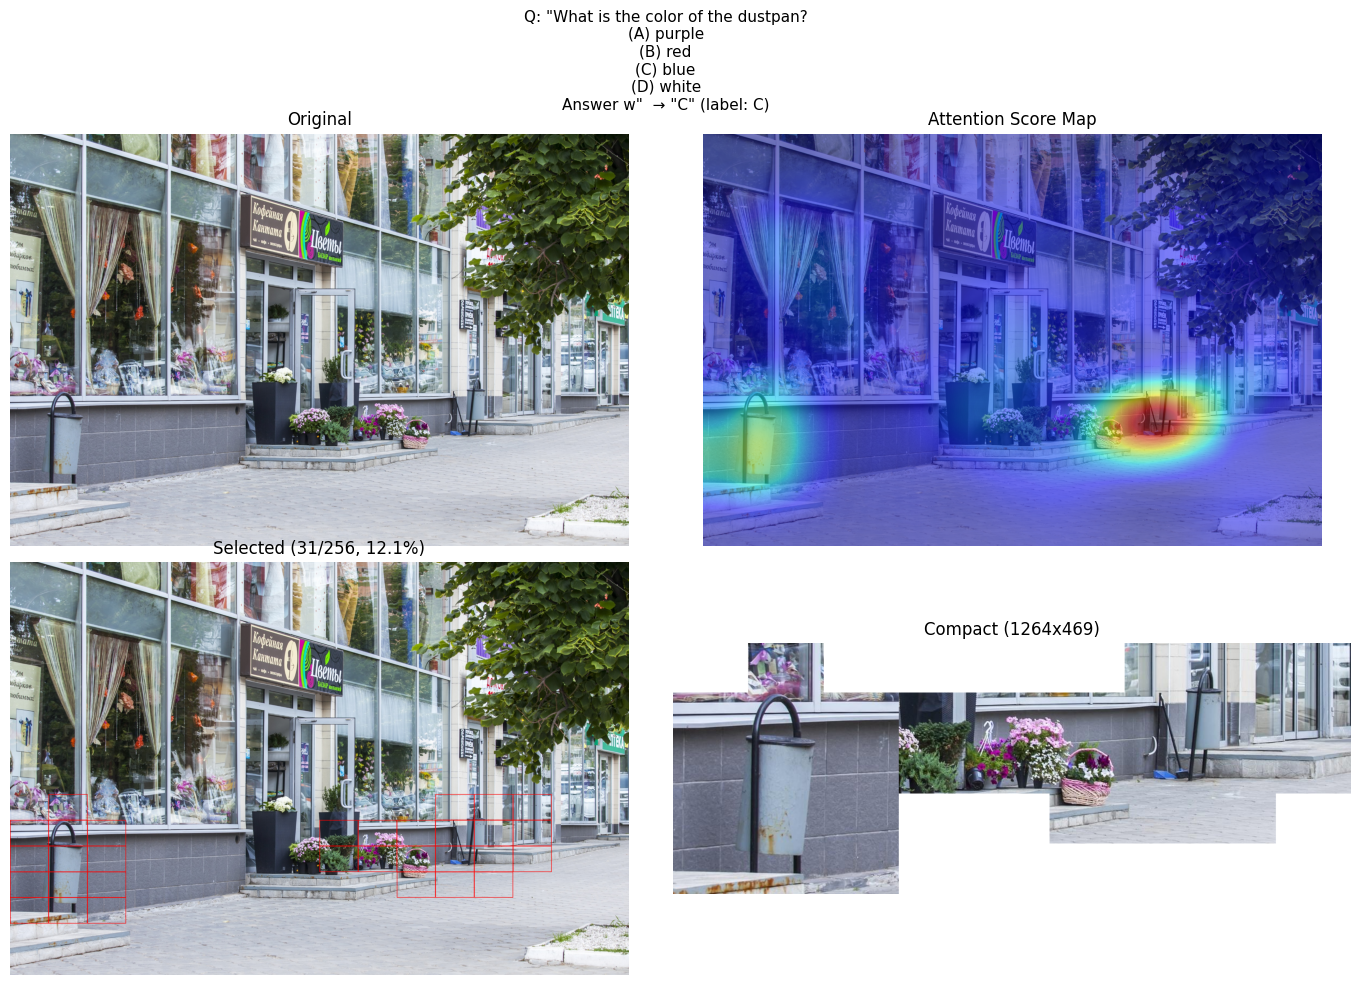

In [8]:
# ── 参数 ──
dataset_dir = "datasets/vstar_bench"
anno_file = "test_questions.jsonl"
sample_idx = 1

with open(os.path.join(dataset_dir, anno_file), "r") as f:
    samples = [json.loads(line) for line in f]
sample = samples[sample_idx]
img_path = os.path.join(dataset_dir, sample["image"])
question = sample["text"]
label = sample["label"]
print(f"Question: {question}")
print(f"Label:    {label}")
image = Image.open(img_path).convert("RGB")

import tempfile
tmp = tempfile.NamedTemporaryFile(suffix=".jpg", delete=False)
image.save(tmp.name)
tmp.close()

pred_text = tree_model.infer(
    tokenizer=tokenizer,
    image_path=tmp.name,
    question=question,
    max_new_tokens=16,
)
os.unlink(tmp.name)

pred_option = extract_option_letter(pred_text)
print(f"Prediction:  {pred_text}")
print(f"Pred option: {pred_option}")
print(f"Correct:     {pred_option == label}")

# ── 可视化 ──
full_score_map = tree_model._debug_full_score_map.cpu().float()  # [16, 16]
scores_up = F.interpolate(
    full_score_map.unsqueeze(0).unsqueeze(0),
    size=(image.height, image.width),
    mode="bicubic", align_corners=False,
).squeeze().cpu().numpy()
scores_up = (scores_up - scores_up.min()) / (scores_up.max() - scores_up.min() + 1e-6)

orig_with_boxes = image.copy()
draw = ImageDraw.Draw(orig_with_boxes)
merged_bboxes = getattr(tree_model, "_debug_merged_bboxes", None)
if merged_bboxes:
    for b in merged_bboxes:
        draw.rectangle([b[0], b[1], b[2], b[3]], outline="red", width=2)

compact_tiles = getattr(tree_model, "_debug_compact_tiles", None)
compact_img = compact_tiles[0] if compact_tiles else image

num_selected = getattr(tree_model, "_debug_num_selected_tokens", [])
num_total    = getattr(tree_model, "_debug_num_total_tokens", [])
n_sel = num_selected[0] if num_selected else 0
n_tot = num_total[0]    if num_total    else 0
ratio  = n_sel / n_tot if n_tot > 0 else 0.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0][0].imshow(image)
axes[0][0].set_title("Original")
axes[0][0].axis("off")
axes[0][1].imshow(image)
axes[0][1].imshow(scores_up, cmap="jet", alpha=0.5)
axes[0][1].set_title("Attention Score Map")
axes[0][1].axis("off")
axes[1][0].imshow(orig_with_boxes)
axes[1][0].set_title(f"Selected ({n_sel}/{n_tot}, {ratio:.1%})")
axes[1][0].axis("off")
axes[1][1].imshow(compact_img)
axes[1][1].set_title(f"Compact ({compact_img.size[0]}x{compact_img.size[1]})")
axes[1][1].axis("off")
plt.suptitle(f'Q: "{question[:80]}"  → "{pred_option}" (label: {label})', fontsize=11)
plt.tight_layout()
plt.show()

In [3]:
# tree internvl + vstar
pred_file = run_vstar_inference_internvl(
    model=tree_model,
    tokenizer=tokenizer,
    model_type="tree_internvl",
    run_name="tree_internvl_global_compact",
    max_samples=None,
)
evaluate_vstar_predictions(pred_file)

Running V-Star [tree_internvl]:   0%|          | 0/191 [00:00<?, ?it/s]The tokenizer you are loading from 'checkpoints/InternVL3-8B' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 41, original: 256, ratio: 16.0%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 41, original: 256, ratio: 16.0%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


...

Running V-Star [tree_internvl]:  99%|█████████▉| 190/191 [03:28<00:01,  1.00s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 85, original: 256, ratio: 33.2%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Running V-Star [tree_internvl]: 100%|██████████| 191/191 [03:29<00:00,  1.10s/it]

[TIME]   mean GPU time    = 0.979s  (n=186)
[MEMORY] mean peak memory = 17.74GB
[STATS] mean selected tokens = 74.21
[STATS] mean total tokens    = 256.00
[STATS] mean select ratio    = 0.2899
[STATS] select ratio by category:
  - direct_attributes: 0.2630 (n=115)
  - relative_position: 0.3306 (n=76)
[INFO] Saved predictions to: datasets/vstar_bench/vstar_predictions_tree_internvl_global_compact.jsonl
Accuracy: 0.8325 (159/191)
  - direct_attributes: 0.8435 (97/115)
  - relative_position: 0.8158 (62/76)


0.8324607329842932

# HR-Bench

In [10]:
# base internvl + hrbench 4k
pred_file = run_hrbench_inference_internvl(
    model=tree_model,
    tokenizer=tokenizer,
    split="4k",
    model_type="base_internvl",
    run_name="base_internvl_compa",
    max_samples=None,
)
evaluate_hrbench_predictions(pred_file)

Running HR-Bench 4k [base_internvl]:   0%|          | 0/800 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Running HR-Bench 4k [base_internvl]:   1%|▏         | 10/800 [00:11<14:53,  1.13s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token

[INFO] Saved predictions to: datasets/hr_bench/hr_bench_4k_predictions_base_internvl_compa.jsonl
Accuracy: 0.6238 (499/800)


0.62375

In [11]:
# tree internvl + hrbench 4k
pred_file = run_hrbench_inference_internvl(
    model=tree_model,
    tokenizer=tokenizer,
    split="4k",
    model_type="tree_internvl",
    run_name="tree_internvl_global_compact",
    max_samples=None,
)
evaluate_hrbench_predictions(pred_file)

Running HR-Bench 4k [tree_internvl]:   0%|          | 0/800 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 43, original: 256, ratio: 16.8%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 42, original: 256, ratio: 16.4%


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Running HR-Bench 4k [tree_internvl]: 100%|█████████▉| 799/800 [19:45<00:01,  1.47s/it]Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


[TREE] selected tokens: 73, original: 256, ratio: 28.5%


Running HR-Bench 4k [tree_internvl]: 100%|██████████| 800/800 [19:46<00:00,  1.48s/it]

[STATS] mean selected tokens = 55.68
[STATS] mean total tokens    = 256.00
[STATS] mean select ratio    = 0.2175
[STATS] select ratio by category:
  - cross: 0.2246 (n=400)
  - single: 0.2105 (n=400)
[STATS] select ratio by cycle_category:
  - 0: 0.2176 (n=200)
  - 1: 0.2192 (n=200)
  - 2: 0.2167 (n=200)
  - 3: 0.2166 (n=200)
[INFO] Saved predictions to: datasets/hr_bench/hr_bench_4k_predictions_tree_internvl_global_compact.jsonl
Accuracy: 0.6987 (559/800)


0.69875

In [ ]:
# base internvl + hrbench 8k
pred_file = run_hrbench_inference_internvl(
    model=tree_model,
    tokenizer=tokenizer,
    split="8k",
    model_type="base_internvl",
    run_name="base_internvl_hrbench8k",
    max_samples=None,
)
evaluate_hrbench_predictions(pred_file)

In [ ]:
# tree internvl + hrbench 8k
pred_file = run_hrbench_inference_internvl(
    model=tree_model,
    tokenizer=tokenizer,
    split="8k",
    model_type="tree_internvl",
    run_name="tree_internvl_global_compact",
    max_samples=None,
)
evaluate_hrbench_predictions(pred_file)